In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [4]:
# FOR ALL Large SCALE TRIALS
dx = 0.5e-6; #[m]
tau=1; #0.95; # best accuracy
vis=1e-3; #[pa*s]
rho=1e3; #[kg/m^3]
dt=(tau-0.5)/3*dx**2*rho/vis;
dm = rho*dx*dx*dx; # water mass
kBT=1.3806e-23*296; # thermal energy
Cube_Side_Length = 210; #[NU]
A_Cross = (Cube_Side_Length*dx)**2; # [m^2]
A_Cross_Small = (130*dx)**2;

L_0 = 210*dx;

Small_Forces = [];
# 1 [nN]:
Force_1 = .0277;
Small_Forces.append(Force_1);
# 5 [nN]:
Force_5 = .1388;
Small_Forces.append(Force_5);
# 10 [nN]:
Force_10 = .277;
Small_Forces.append(Force_10);
# 20 [nN]:
Force_20 = .5555;
Small_Forces.append(Force_20);
# 40 [nN]:
Force_40 = 1.1111;
Small_Forces.append(Force_40);
# 60 [nN]:
Force_60 = 1.6666;
Small_Forces.append(Force_60);
# 80 [nN]:
Force_80 = 2.2222;
Small_Forces.append(Force_80);
# 100 [nN]:
Force_100 = 2.7777777777777763;
Small_Forces.append(Force_100);


#For more forces:
Force_200 = 2*Force_100 
Small_Forces.append(Force_200);
Force_300 = 3*Force_100 
Small_Forces.append(Force_300);
Force_400 = 4*Force_100 
Small_Forces.append(Force_400);
Force_500 = 5*Force_100 
Small_Forces.append(Force_500);
Force_600 = 6*Force_100 
Small_Forces.append(Force_600);
Force_700 = 7*Force_100 
Small_Forces.append(Force_700);
Force_800 = 8*Force_100 
Small_Forces.append(Force_800);

Target_Stress = np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross_Small;

#Small_Forces = Target_Stress*A_Cross*(dt**2/dm/dx)
Small_Forces = Target_Stress*A_Cross
print(Small_Forces)

print(1000e-9)

[2.60216095e-09 1.30389870e-08 2.60216095e-08 5.21841302e-08
 1.04377654e-07 1.56561785e-07 2.08755309e-07 2.60946746e-07
 5.21893491e-07 7.82840237e-07 1.04378698e-06 1.30473373e-06
 1.56568047e-06 1.82662722e-06 2.08757396e-06]
1e-06


In [3]:
# To calculate unitless force:
Force = 100e-9;

Force_LB = Force*dt**2/dm/dx;

print(Force_LB)

2.7777777777777763


0.46649999999999986   1.1826745562130188
0.543552380952381   2.3602366863905346
0.6769571428571429   4.733254437869827
0.9027047619047618   9.467360946745568
1.0974238095238096   14.200615384615396
1.2842047619047618   18.934721893491137
1.4532190476190476   23.66863905325444
2.087614285714286   47.33727810650888
2.4853571428571426   71.00591715976333
2.749095238095238   94.67455621301777
2.948857142857143   118.34319526627225
3.0986619047619053   142.01183431952666
3.2152714285714286   165.68047337278117
3.309285714285714   189.34911242603553


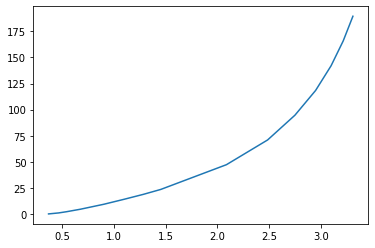

In [8]:
#Using Random Number Seed 1 Z stretch Small Scale
Tip_Num = 427;
Base_Num = 623;
Mobile_Num = 6971;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    Tip_Forces.append(Tip_Force)
    #print('#fix             3 tip addforce',str(Tip_Force), '0 0') # For X
    #print('#fix             3 tip addforce 0 0 ', str(Tip_Force)) # For Z

#Unitless Force vs displacement Seed 1: Z direction
Force_Dp_1_Z = np.array([
    [287.464,Tip_Forces[0]],
    [307.965,Tip_Forces[1]],
    [324.146,Tip_Forces[2]],
    [352.161,Tip_Forces[3]],
    [399.568,Tip_Forces[4]],
    [440.459,Tip_Forces[5]],
    [479.683,Tip_Forces[6]], 
    [515.176,Tip_Forces[7]],
    [648.399,Tip_Forces[8]],
    [731.925,Tip_Forces[9]],
    [787.31,Tip_Forces[10]],
    [829.26,Tip_Forces[11]],
    [860.719,Tip_Forces[12]],
    [885.207,Tip_Forces[13]],
    [904.95,Tip_Forces[14]],
])

Force_Len_1_Z = [Force_Dp_1_Z[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_Z = [(dx*Force_Dp_1_Z[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

plt.plot(Stress_Strain_1_Z[0],Stress_Strain_1_Z[1])
for i in range(1,len(Stress_Strain_1_Z[0]),1):
    stress = Stress_Strain_1_Z[0][i];
    strain = Stress_Strain_1_Z[1][i];
    print(str(stress),' ',str(strain))

0.38193809523809513   1.1826745562130188
0.47082857142857154   2.3602366863905346
0.5956857142857143   4.733254437869827
0.8018047619047619   9.467360946745568
0.989304761904762   14.200615384615396
1.1722095238095238   18.934721893491137
1.335961904761905   23.66863905325444
1.9261285714285712   47.33727810650888
2.2825761904761905   71.00591715976333
2.5115   94.67455621301777
2.6683857142857144   118.34319526627225
2.7818571428571435   142.01183431952666
2.8675333333333333   165.68047337278117
2.9343190476190473   189.34911242603553


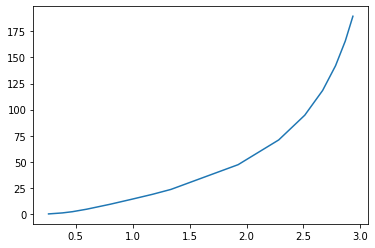

In [16]:
#Using Random Number Seed 1 X stretch
Tip_Num = 418;
Base_Num = 665;
Mobile_Num = 6929;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    #print('#fix             7 tip addforce',str(Tip_Force), '0 0')
    Tip_Forces.append(Tip_Force)

#Unitless Force vs displacement Seed 1: X direction
Force_Dp_1_X = np.array([
    [264.873,Tip_Forces[0]],
    [290.207,Tip_Forces[1]],
    [308.874,Tip_Forces[2]],
    [335.094,Tip_Forces[3]],
    [378.379,Tip_Forces[4]],
    [417.754,Tip_Forces[5]],
    [456.164,Tip_Forces[6]], 
    [490.552,Tip_Forces[7]],
    [614.487,Tip_Forces[8]],
    [689.341,Tip_Forces[9]],
    [737.415,Tip_Forces[10]],
    [770.361,Tip_Forces[11]],
    [794.19,Tip_Forces[12]],
    [812.182,Tip_Forces[13]],
    [826.207,Tip_Forces[14]],
])

Force_Len_1_X = [Force_Dp_1_X[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_X = [(dx*Force_Dp_1_X[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

#print(Stress_Strain_1_X)

plt.plot(Stress_Strain_1_X[0],Stress_Strain_1_X[1])
for i in range(1,len(Stress_Strain_1_X[0]),1):
    stress = Stress_Strain_1_X[0][i];
    strain = Stress_Strain_1_X[1][i];
    print(str(stress),' ',str(strain))

0.3954428571428572   1.1826745562130188
0.4855952380952384   2.3602366863905346
0.6258523809523809   4.733254437869827
0.8666333333333335   9.467360946745568
1.0802761904761906   14.200615384615396
1.273195238095238   18.934721893491137
1.4453666666666671   23.66863905325444
2.070847619047619   47.33727810650888
2.4490809523809527   71.00591715976333
2.6956999999999995   94.67455621301777
2.8688095238095244   118.34319526627225
2.993057142857143   142.01183431952666
3.0959571428571424   165.68047337278117
3.1674523809523807   189.34911242603553


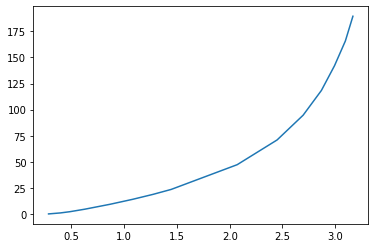

In [15]:
#Using Random Number Seed 1 Y stretch Small Scale
Tip_Num = 373;
Base_Num = 716;
Mobile_Num = 6878;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    Tip_Forces.append(Tip_Force)
    #print('#fix             3 tip addforce',str(Tip_Force), '0 0') # For X
    #print('#fix             3 tip addforce 0 ',str(Tip_Force),' 0') # For Y
    #print('#fix             3 tip addforce 0 0 ', str(Tip_Force)) # For Z

#Unitless Force vs displacement Seed 1: Z direction
Force_Dp_1_Z = np.array([
    [269.463,Tip_Forces[0]],
    [293.043,Tip_Forces[1]],
    [311.975,Tip_Forces[2]],
    [341.429,Tip_Forces[3]],
    [391.993,Tip_Forces[4]],
    [436.858,Tip_Forces[5]],
    [477.371,Tip_Forces[6]], 
    [513.527,Tip_Forces[7]],
    [644.878,Tip_Forces[8]],
    [724.307,Tip_Forces[9]],
    [776.097,Tip_Forces[10]],
    [812.45,Tip_Forces[11]],
    [838.542,Tip_Forces[12]],
    [860.151,Tip_Forces[13]],
    [875.165,Tip_Forces[14]],
])

Force_Len_1_Z = [Force_Dp_1_Z[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_Z = [(dx*Force_Dp_1_Z[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

plt.plot(Stress_Strain_1_Z[0],Stress_Strain_1_Z[1])
for i in range(1,len(Stress_Strain_1_Z[0]),1):
    stress = Stress_Strain_1_Z[0][i];
    strain = Stress_Strain_1_Z[1][i];
    print(str(stress),' ',str(strain))